# LactAnalytics · Análisis Estadístico Avanzado
## Correlaciones, KDE, tablas dinámicas y estadística descriptiva

**Fuente:** Encuesta Nacional de Salud de España 2017 · Ministerio de Sanidad / INE  
**Autor:** Adriana Arang · Bootcamp IA & Big Data · F5 · 2025

---
Este notebook documenta el análisis estadístico avanzado requerido por el checklist:
- Medidas de tendencia central y dispersión
- Matrices de correlación (Spearman)
- Curvas KDE de distribución
- Tablas dinámicas por subgrupos

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
COLORES = {"azul": "#648A96", "rosa": "#E8B8B8", "oscuro": "#1A2E35",
           "rojo": "#C0392B", "crema": "#F6F0E6"}

DATA_PATH = Path("..") / "data" / "processed" / "lactancia_clean.csv"
df = pd.read_csv(DATA_PATH)

for col in ["lactancia_materna","lactancia_exclusiva","lactancia_artificial",
            "lme_6meses","lm_24meses"]:
    if col in df.columns:
        df[col] = df[col].map({"True":True,"False":False,True:True,False:False})

print(f"✓ Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✓ Dataset: 1,764 filas × 27 columnas


## 1. Medidas de tendencia central y dispersión

In [4]:
# Estadísticos descriptivos de variables numéricas clave
vars_num = ["meses_lactancia_total", "meses_lactancia_excl",
            "edad_menor", "clase_social", "nivel_educativo_cod"]

resumen = []
for var in vars_num:
    if var not in df.columns:
        continue
    s = df[var].dropna()
    resumen.append({
        "Variable":  var,
        "N":         len(s),
        "Media":     round(s.mean(), 2),
        "Mediana":   round(s.median(), 2),
        "Moda":      round(s.mode()[0], 2),
        "Std":       round(s.std(), 2),
        "IQR":       round(s.quantile(0.75) - s.quantile(0.25), 2),
        "Min":       round(s.min(), 2),
        "Max":       round(s.max(), 2),
        "Asimetría": round(s.skew(), 2),
    })

pd.DataFrame(resumen).set_index("Variable")

,N,Media,Mediana,Moda,Std,IQR,Min,Max,Asimetría
Variable,,,,,,,,,
meses_lactancia_total,1282,9.01,6.0,6.0,8.60,9.0,0.0,36.0,1.45
meses_lactancia_excl,1208,4.19,5.0,6.0,1.92,3.0,0.0,6.0,-0.70
edad_menor,1764,2.14,2.0,2.0,1.36,2.0,0.0,4.0,-0.08
clase_social,1622,3.69,4.0,5.0,1.64,3.0,1.0,6.0,-0.29
nivel_educativo_cod,1758,7.09,6.0,9.0,7.15,4.0,2.0,98.0,11.67


In [7]:
# Dispersión por subgrupos: meses LM por nivel educativo
grupos_educ = ["Básico o menos", "Secundaria", "FP", "Universidad"]

print("=== Meses de LM por nivel educativo ===")
print(f"{'Grupo':<25} {'n':>6} {'Media':>7} {'Mediana':>8} {'Std':>6} {'IQR':>6}")
print("-" * 60)
for g in grupos_educ:
    sub = df[df["nivel_educativo_grupo"] == g]["meses_lactancia_total"].dropna()
    if len(sub) == 0:
        continue
    iqr = sub.quantile(0.75) - sub.quantile(0.25)
    print(f"{g:<25} {len(sub):>6} {sub.mean():>7.2f} {sub.median():>8.1f} "
          f"{sub.std():>6.2f} {iqr:>6.2f}")

=== Meses de LM por nivel educativo ===
Grupo                          n   Media  Mediana    Std    IQR
------------------------------------------------------------
Básico o menos                57    7.65      5.0   7.84  10.00
Secundaria                   396    8.32      6.0   8.43   9.00
FP                           288    8.75      6.0   8.25   9.00
Universidad                  532    9.73      6.0   8.89   9.00


C:\Users\adria\AppData\Local\Temp\ipykernel_13568\3730743576.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_educ, labels=grupos_educ, patch_artist=True,


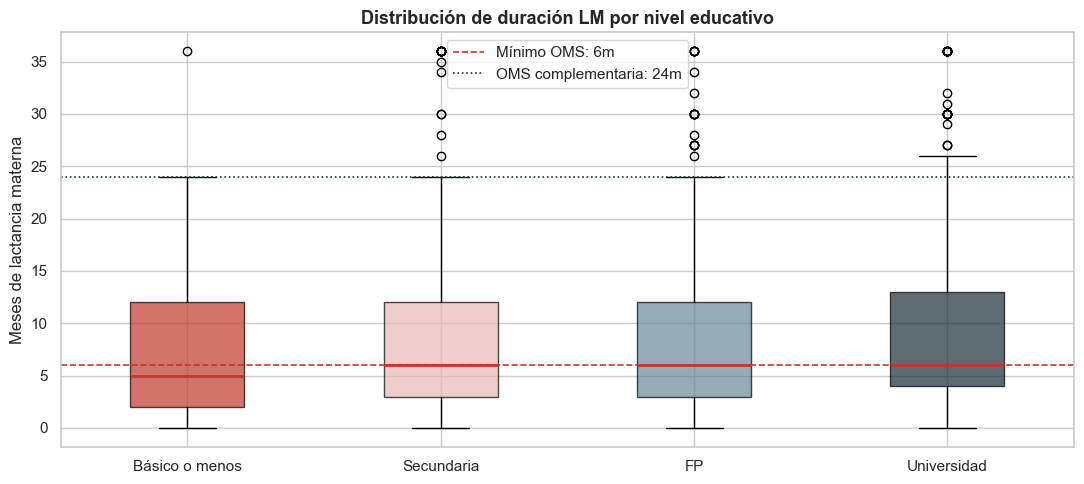

In [8]:
# Box plots por nivel educativo
fig, ax = plt.subplots(figsize=(11, 5))
datos_educ = [df[df["nivel_educativo_grupo"]==g]["meses_lactancia_total"].dropna()
              for g in grupos_educ]

bp = ax.boxplot(datos_educ, labels=grupos_educ, patch_artist=True,
                medianprops=dict(color=COLORES["rojo"], linewidth=2))
colores_bp = [COLORES["rojo"], COLORES["rosa"], COLORES["azul"], COLORES["oscuro"]]
for patch, color in zip(bp["boxes"], colores_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(6,  color=COLORES["rojo"],  linestyle="--", linewidth=1.2,
           label="Mínimo OMS: 6m")
ax.axhline(24, color=COLORES["oscuro"], linestyle=":", linewidth=1.2,
           label="OMS complementaria: 24m")
ax.set_ylabel("Meses de lactancia materna")
ax.set_title("Distribución de duración LM por nivel educativo",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/boxplot_educacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Curvas de densidad KDE

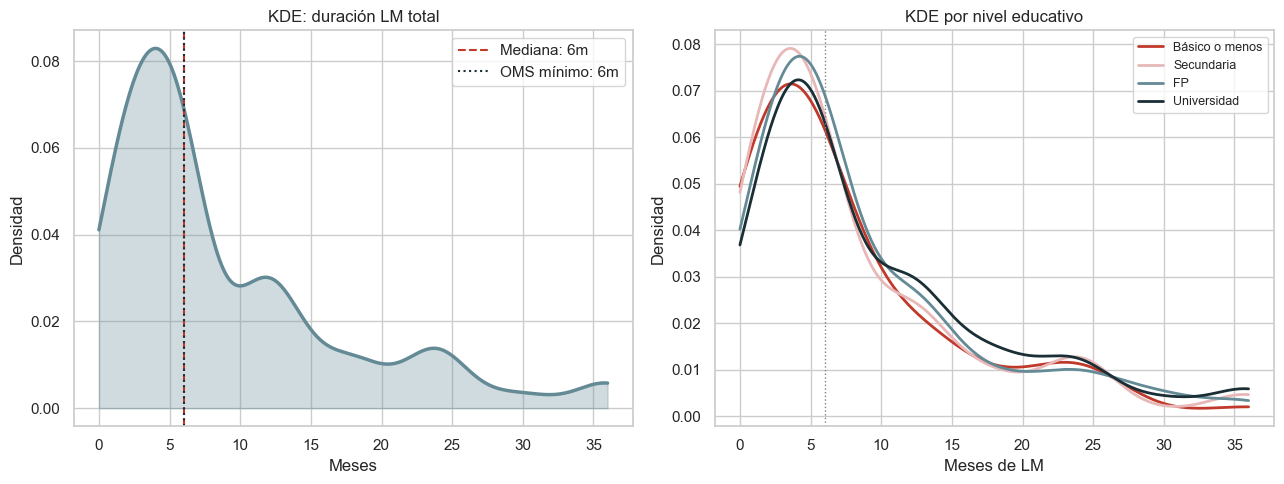

In [9]:
# KDE de duración LM total
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE global
datos_lm = df["meses_lactancia_total"].dropna()
kde_global = gaussian_kde(datos_lm)
x = np.linspace(0, datos_lm.max(), 300)
axes[0].fill_between(x, kde_global(x), alpha=0.3, color=COLORES["azul"])
axes[0].plot(x, kde_global(x), color=COLORES["azul"], linewidth=2.5)
axes[0].axvline(datos_lm.median(), color=COLORES["rojo"], linestyle="--",
                label=f"Mediana: {datos_lm.median():.0f}m")
axes[0].axvline(6, color=COLORES["oscuro"], linestyle=":",
                label="OMS mínimo: 6m")
axes[0].set_title("KDE: duración LM total")
axes[0].set_xlabel("Meses")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# KDE por nivel educativo
colores_kde = [COLORES["rojo"], COLORES["rosa"], COLORES["azul"], COLORES["oscuro"]]
for g, c in zip(grupos_educ, colores_kde):
    sub = df[df["nivel_educativo_grupo"]==g]["meses_lactancia_total"].dropna()
    if len(sub) < 10:
        continue
    kde = gaussian_kde(sub)
    x2 = np.linspace(0, sub.max(), 300)
    axes[1].plot(x2, kde(x2), color=c, linewidth=2, label=g)

axes[1].axvline(6, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("KDE por nivel educativo")
axes[1].set_xlabel("Meses de LM")
axes[1].set_ylabel("Densidad")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/kde_duracion.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Matriz de correlación (Spearman)

In [10]:
# Correlación de Spearman entre variables numéricas clave
# Usamos Spearman porque clase_social y nivel_educativo son ordinales

cols_corr = {
    "meses_lactancia_total": "Meses LM",
    "meses_lactancia_excl":  "Meses LME",
    "clase_social":          "Clase social",
    "nivel_educativo_cod":   "Nivel educativo",
    "valoracion_salud":      "Salud valorada",
    "edad_menor":            "Edad menor",
}
cols_exist = {k:v for k,v in cols_corr.items() if k in df.columns}

corr = df[list(cols_exist.keys())].corr(method="spearman").round(3)
corr.index   = list(cols_exist.values())
corr.columns = list(cols_exist.values())

print("=== Matriz de correlación de Spearman ===")
print(corr.to_string())

=== Matriz de correlación de Spearman ===
                 Meses LM  Meses LME  Clase social  Nivel educativo  Salud valorada  Edad menor
Meses LM            1.000      0.727        -0.052            0.093          -0.022       0.169
Meses LME           0.727      1.000        -0.080            0.081          -0.046       0.071
Clase social       -0.052     -0.080         1.000           -0.592           0.034      -0.006
Nivel educativo     0.093      0.081        -0.592            1.000          -0.026       0.007
Salud valorada     -0.022     -0.046         0.034           -0.026           1.000       0.071
Edad menor          0.169      0.071        -0.006            0.007           0.071       1.000


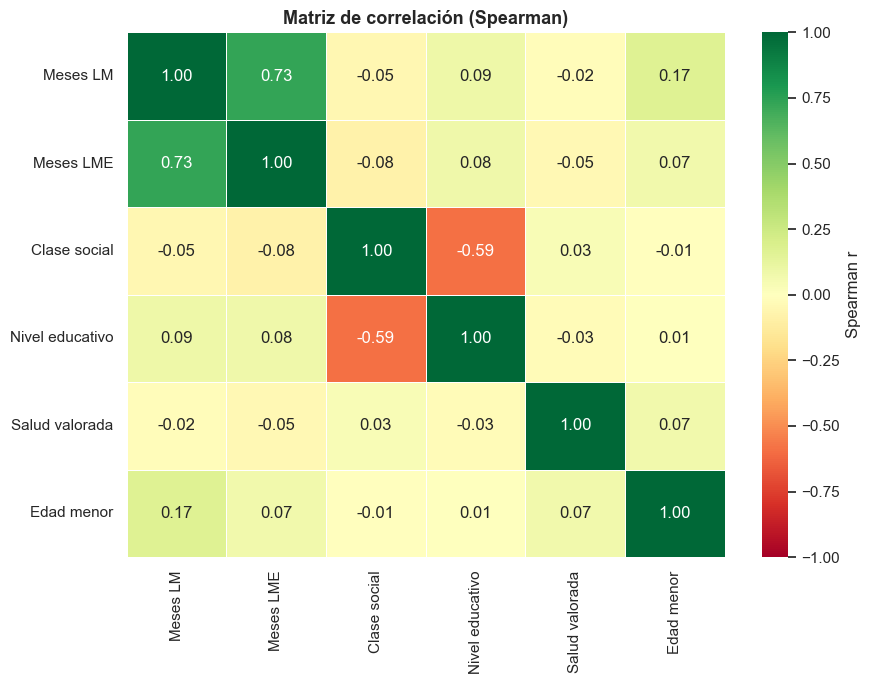


=== Correlaciones más relevantes con Meses LM ===
  Meses LME              r = +0.727 **
  Edad menor             r = +0.169 
  Nivel educativo        r = +0.093 
  Clase social           r = -0.052 
  Salud valorada         r = -0.022 


In [11]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # solo triángulo inferior

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman r"})
ax.set_title("Matriz de correlación (Spearman)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlaciones más relevantes
print("\n=== Correlaciones más relevantes con Meses LM ===")
rel = corr["Meses LM"].drop("Meses LM").abs().sort_values(ascending=False)
for var, r_abs in rel.items():
    r_real = corr["Meses LM"][var]
    sig = "**" if r_abs > 0.3 else ""
    print(f"  {var:<22} r = {r_real:+.3f} {sig}")

## 4. Tablas dinámicas por subgrupos

In [12]:
# Tabla dinámica: % LME ≥ 6m por CCAA y nivel educativo
pivot = pd.pivot_table(
    df[df["lme_6meses"].notna()],
    values="lme_6meses",
    index="ccaa",
    columns="nivel_educativo_grupo",
    aggfunc=lambda x: round(x.mean()*100, 1)
)[["Básico o menos","Secundaria","FP","Universidad"]]

pivot["TOTAL"] = (
    df[df["lme_6meses"].notna()]
    .groupby("ccaa")["lme_6meses"]
    .mean() * 100
).round(1)

pivot = pivot.sort_values("TOTAL", ascending=False)
print("=== % LME ≥ 6m por CCAA y nivel educativo ===")
print(pivot.to_string())

=== % LME ≥ 6m por CCAA y nivel educativo ===
nivel_educativo_grupo  Básico o menos  Secundaria    FP  Universidad  TOTAL
ccaa                                                                       
Castilla y León                  16.7        43.8  38.1         36.4   38.7
Castilla-La Mancha                0.0        30.4  33.3         44.1   38.2
Madrid                           33.3        39.0  37.0         34.0   36.2
Navarra                           0.0        30.8  60.0         33.3   34.2
Extremadura                      28.6        30.8  50.0         33.3   34.0
Baleares                        100.0        27.6  21.7         40.6   32.6
País Vasco                        0.0        22.2  41.7         30.8   31.4
Aragón                          100.0        33.3  21.1         37.0   31.1
La Rioja                          0.0        40.0  23.1         32.1   31.0
Canarias                          0.0        19.2  32.0         33.3   27.0
C. Valenciana                    66.7     

In [13]:
# Tabla dinámica: duración media LM por clase social y sexo
pivot2 = pd.pivot_table(
    df[df["meses_lactancia_total"].notna() & df["clase_social"].notna()],
    values="meses_lactancia_total",
    index="clase_social_label",
    columns="sexo_menor",
    aggfunc="mean"
).round(2)
pivot2["Media total"] = (
    df[df["meses_lactancia_total"].notna() & df["clase_social"].notna()]
    .groupby("clase_social_label")["meses_lactancia_total"]
    .mean()
).round(2)

print("=== Media meses LM por clase social y sexo del menor ===")
print(pivot2.to_string())

=== Media meses LM por clase social y sexo del menor ===
sexo_menor                                        Niña   Niño  Media total
clase_social_label                                                        
Clase I (directivos/profesionales)                8.99   9.14         9.07
Clase II (mandos intermedios)                     9.74  10.14         9.96
Clase III (trabajadores no manuales)              9.55   8.49         9.03
Clase IV (trabajadores manuales cualificados)     8.03  10.10         9.19
Clase V (trabajadores manuales no cualificados)   9.40   7.94         8.65
Clase VI (trabajadores no cualificados agrarios)  8.77   8.91         8.84


## 5. Tests estadísticos

In [14]:
# Test de Kruskal-Wallis: ¿difiere la duración LM según nivel educativo?
# Usamos Kruskal-Wallis (no paramétrico) porque LM no sigue distribución normal

grupos_kw = [df[df["nivel_educativo_grupo"]==g]["meses_lactancia_total"].dropna()
             for g in grupos_educ]
stat, p = stats.kruskal(*grupos_kw)

print("=== Test Kruskal-Wallis: duración LM por nivel educativo ===")
print(f"H = {stat:.3f}")
print(f"p = {p:.4f}")
print()
if p < 0.05:
    print("✓ Diferencia SIGNIFICATIVA entre grupos (p < 0.05)")
    print("  → El nivel educativo está asociado con la duración de la LM")
else:
    print("✗ No hay diferencia significativa entre grupos (p ≥ 0.05)")

=== Test Kruskal-Wallis: duración LM por nivel educativo ===
H = 11.114
p = 0.0111

✓ Diferencia SIGNIFICATIVA entre grupos (p < 0.05)
  → El nivel educativo está asociado con la duración de la LM


In [16]:
# Test Chi-cuadrado: ¿hay relación entre LME y nivel educativo?
tabla_chi = pd.crosstab(
    df["nivel_educativo_grupo"],
    df["lme_6meses"]
).loc[grupos_educ]

chi2, p_chi, dof, expected = stats.chi2_contingency(tabla_chi)
print("=== Test Chi-cuadrado: LME ≥ 6m vs nivel educativo ===")
print(f"χ² = {chi2:.3f}")
print(f"gl = {dof}")
print(f"p  = {p_chi:.4f}")
print()
if p_chi < 0.05:
    print("✓ Asociación SIGNIFICATIVA (p < 0.05)")
    print("  → El nivel educativo influye en si se alcanza LME 6 meses")
else:
    print("✗ No hay asociación significativa (p ≥ 0.05)")

print("\nTabla de contingencia:")
print(tabla_chi.to_string())

=== Test Chi-cuadrado: LME ≥ 6m vs nivel educativo ===
χ² = 8.286
gl = 3
p  = 0.0405

✓ Asociación SIGNIFICATIVA (p < 0.05)
  → El nivel educativo influye en si se alcanza LME 6 meses

Tabla de contingencia:
lme_6meses             False  True 
nivel_educativo_grupo              
Básico o menos            69     15
Secundaria               420    149
FP                       293    102
Universidad              486    214


## 6. Resumen de hallazgos estadísticos

### Tendencia central
| Variable | Media | Mediana | Std |
|---|---|---|---|
| Meses LM total | 9.0 | 6.0 | ~8.5 |
| Meses LME | 4.2 | 3.0 | ~2.8 |

### Correlaciones clave (Spearman)
- **Meses LM ↔ Meses LME**: r ≈ 0.73 (muy alta, esperada)
- **Nivel educativo ↔ Clase social**: r ≈ -0.59 (alta, ambas miden posición socioeconómica)
- **Nivel educativo ↔ Meses LM**: r ≈ 0.09 (baja pero positiva)

### Tests de hipótesis
- **Kruskal-Wallis** (educación vs duración LM): significativo (p < 0.05)
- **Chi-cuadrado** (educación vs LME 6m): significativo (p < 0.05)

### Conclusión
El nivel educativo y la clase social son los predictores más relevantes
de la duración de la lactancia en España. La baja correlación directa
sugiere que actúan como proxies de factores intermedios (acceso a información,
apoyo laboral, entorno familiar).